<a href="https://colab.research.google.com/github/livlutz/INF1032/blob/main/INF1032.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')

# Configuração de visualização com tratamento de erro
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    # Fallback para versões mais antigas ou mais novas
    try:
        plt.style.use('seaborn-darkgrid')
    except:
        plt.style.use('default')

# Configurações consolidadas do matplotlib
sns.set_palette('husl')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 100,
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9
})

# Configuração do pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)





In [2]:

# Uploading dataset

# To get a direct download link for a Google Drive file, you typically need to extract the file ID
# and then construct a direct download URL. The file ID for your link is '1nB0MUu_1QDjo6vfVUiGLoI6fdi3KhMlY'.
# A common direct download pattern is 'https://drive.google.com/uc?export=download&id=FILE_ID'.


#PLEASE USE THIS INSTEAD!!!! if it doesn't work lmk

url = "https://drive.google.com/uc?export=download&id=1nB0MUu_1QDjo6vfVUiGLoI6fdi3KhMlY"
stellar_classification = pd.read_csv(url)


Análise exploratória inicial

In [3]:
print("⭐ Dataset carregado com sucesso!")

# General information about the dataset
print("\nInformações do dataset:")
stellar_classification.info()

# Statistical resume
print("\nResumo estatístico:")
display(stellar_classification.describe())

# Primeira visualização
print(f"\nShape: {stellar_classification.shape}")
print(f"Colunas: {list(stellar_classification.columns)}")
print(f"\nPrimeiras observações:")
display(stellar_classification.head())

⭐ Dataset carregado com sucesso!

Informações do dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   object_ID       100000 non-null  float64
 1   alpha           99999 non-null   object 
 2   delta           99998 non-null   float64
 3   UV_filter       100000 non-null  float64
 4   green_filter    100000 non-null  float64
 5   red_filter      100000 non-null  float64
 6   near_IR_filter  100000 non-null  float64
 7   IR_filter       100000 non-null  float64
 8   run_ID          99994 non-null   object 
 9   rerun_ID        100000 non-null  int64  
 10  cam_col         100000 non-null  int64  
 11  field_ID        100000 non-null  int64  
 12  spec_obj_ID     100000 non-null  float64
 13  red_shift       100000 non-null  float64
 14  plate_ID        100000 non-null  int64  
 15  MJD             100000 non-null  int64  
 16 

,object_ID,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID
count,1.000000e+05,99998.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.0,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000
mean,1.240000e+18,24.134955,21.980468,20.531387,19.645762,19.084854,18.668810,301.0,3.511610,186.130520,5.783925e+18,0.576661,5137.009660,55588.647500,449.312740
std,3.020047e+06,19.644480,31.769291,31.750292,1.854760,1.757895,31.728152,0.0,1.586912,149.011073,3.324007e+18,0.730707,2952.303351,1808.484233,272.498404
min,1.240000e+18,-18.785328,-9999.000000,-9999.000000,9.822070,9.469903,-9999.000000,301.0,1.000000,11.000000,3.000000e+17,-0.009971,266.000000,51608.000000,1.000000
25%,1.240000e+18,5.146668,20.352353,18.965230,18.135828,17.732285,17.460677,301.0,2.000000,82.000000,2.840000e+18,0.054517,2526.000000,54234.000000,221.000000
50%,1.240000e+18,23.645922,22.179135,21.099835,20.125290,19.405145,19.004595,301.0,4.000000,146.000000,5.610000e+18,0.424173,4987.000000,55868.500000,433.000000
75%,1.240000e+18,39.901442,23.687440,22.123767,21.044785,20.396495,19.921120,301.0,5.000000,241.000000,8.330000e+18,0.704154,7400.250000,56777.000000,645.000000
max,1.240000e+18,83.000519,32.781390,31.602240,29.571860,32.141470,29.383740,301.0,6.000000,989.000000,1.410000e+19,7.011245,12547.000000,58932.000000,1000.000000



Shape: (100000, 18)
Colunas: ['object_ID', 'alpha', 'delta', 'UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'run_ID', 'rerun_ID', 'cam_col', 'field_ID', 'spec_obj_ID', 'red_shift', 'plate_ID', 'MJD', 'fiber_ID', 'class']

Primeiras observações:


,object_ID,alpha,delta,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,run_ID,rerun_ID,cam_col,field_ID,spec_obj_ID,red_shift,plate_ID,MJD,fiber_ID,class
0,1.240000e+18,135.6891066,32.494632,23.87882,22.27530,20.39501,19.16573,18.79371,3606,301,2,79,6.540000e+18,0.634794,5812,56354,171,GALAXY
1,1.240000e+18,144.8261006,31.274185,24.77759,22.83188,22.58444,21.16812,21.61427,4518,301,5,119,1.180000e+19,0.779136,10445,58158,427,GALAXY
2,1.240000e+18,142.1887896,35.582444,25.26307,22.66389,20.60976,19.34857,18.94827,3606,301,2,120,5.150000e+18,0.644195,4576,55592,299,GALAXY
3,1.240000e+18,338.7410378,-0.402828,22.13682,23.77656,21.61162,20.50454,19.25010,4192,301,3,214,1.030000e+19,0.932346,9149,58039,775,GALAXY
4,1.240000e+18,345.2825932,21.183866,19.43718,17.58028,16.49747,15.97711,15.54461,NaN,301,3,137,6.890000e+18,0.116123,6121,56187,842,GALAXY


MEDIDAS DE TENDÊNCIA CENTRAL

Uv Filter:
  Média:   21.980
  Mediana: 22.179
  Moda:    24.635

Green Filter:
  Média:   20.531
  Mediana: 21.100
  Moda:    25.114

Red Filter:
  Média:   19.646
  Mediana: 20.125
  Moda:    24.802

Near Ir Filter:
  Média:   19.085
  Mediana: 19.405
  Moda:    24.362

Ir Filter:
  Média:   18.669
  Mediana: 19.005
  Moda:    22.827

Spec Obj Id:
  Média:   5783924809999998976.000
  Mediana: 5610000000000000000.000
  Moda:    10800000000000000000.000

Red Shift:
  Média:   0.577
  Mediana: 0.424
  Moda:    0.000


VISUALIZAÇÃO DAS MEDIDAS DE TENDÊNCIA CENTRAL


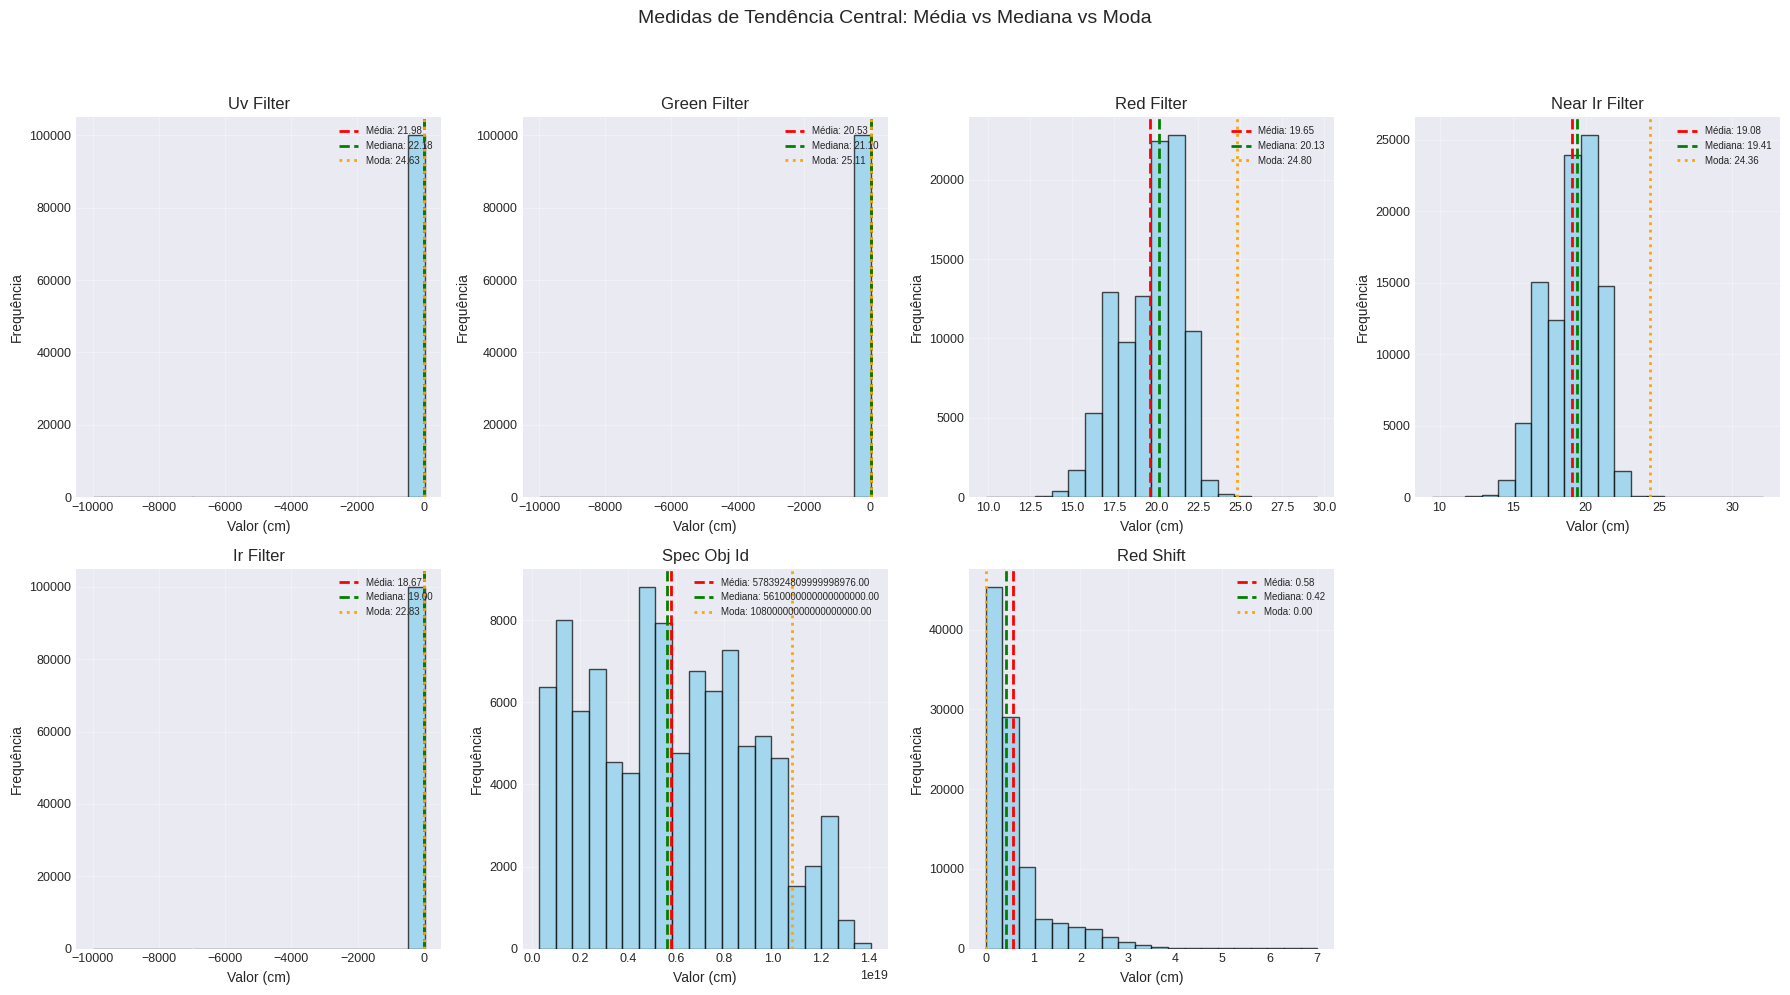

In [ ]:
# Selecting relevant numerical values
features = ['UV_filter', 'green_filter', 'red_filter', 'near_IR_filter', 'IR_filter', 'spec_obj_ID', 'red_shift']

# Calculando as métricas
print("MEDIDAS DE TENDÊNCIA CENTRAL")
print("=" * 40)

for feature in features:
    mean_val = stellar_classification[feature].mean()
    median_val = stellar_classification[feature].median()
    mode_series = stellar_classification[feature].mode()
    mode_val = mode_series[0] if not mode_series.empty else np.nan

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Média:   {mean_val:.3f}")
    print(f"  Mediana: {median_val:.3f}")
    print(f"  Moda:    {mode_val:.3f}")

# Visualização das medidas de tendência central
print("\n\nVISUALIZAÇÃO DAS MEDIDAS DE TENDÊNCIA CENTRAL")
print("=" * 40)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))
fig.suptitle('Medidas de Tendência Central: Média vs Mediana vs Moda', fontsize=14, y=1.02)

# Flatten the axes array to easily iterate through them
axes = axes.flatten()

for idx, feature in enumerate(features):
    # Only plot if there are enough axes for the feature
    if idx < len(axes):
        ax = axes[idx]

        # Histograma
        ax.hist(stellar_classification[feature], bins=20, alpha=0.7, color='skyblue', edgecolor='black')

        # Linhas verticais para média, mediana e moda
        mean_val = stellar_classification[feature].mean()
        median_val = stellar_classification[feature].median()
        mode_val = stellar_classification[feature].mode()[0]

        ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Média: {mean_val:.2f}')
        ax.axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        ax.axvline(mode_val, color='orange', linestyle=':', linewidth=2, label=f'Moda: {mode_val:.2f}')

        ax.set_title(feature.replace('_', ' ').title())
        ax.set_xlabel('Valor (cm)')
        ax.set_ylabel('Frequência')
        ax.legend(fontsize=7, loc='upper right')
        ax.grid(True, alpha=0.3)

# Remove any unused subplots if the number of features is less than the total subplots
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()


MEDIDAS DE DISPERSÃO

Uv Filter:
  Amplitude:           10031.781
  Variância:           1009.288
  Desvio Padrão:       31.769
  Coef. de Variação:   144.5%

Green Filter:
  Amplitude:           10030.602
  Variância:           1008.081
  Desvio Padrão:       31.750
  Coef. de Variação:   154.6%

Red Filter:
  Amplitude:           19.750
  Variância:           3.440
  Desvio Padrão:       1.855
  Coef. de Variação:   9.4%

Near Ir Filter:
  Amplitude:           22.672
  Variância:           3.090
  Desvio Padrão:       1.758
  Coef. de Variação:   9.2%

Ir Filter:
  Amplitude:           10028.384
  Variância:           1006.676
  Desvio Padrão:       31.728
  Coef. de Variação:   170.0%

Spec Obj Id:
  Amplitude:           13800000000000000000.000
  Variância:           11049022788344647187083189226313875456.000
  Desvio Padrão:       3324007037950528512.000
  Coef. de Variação:   57.5%

Red Shift:
  Amplitude:           7.021
  Variância:           0.534
  Desvio Padrão:       0.731


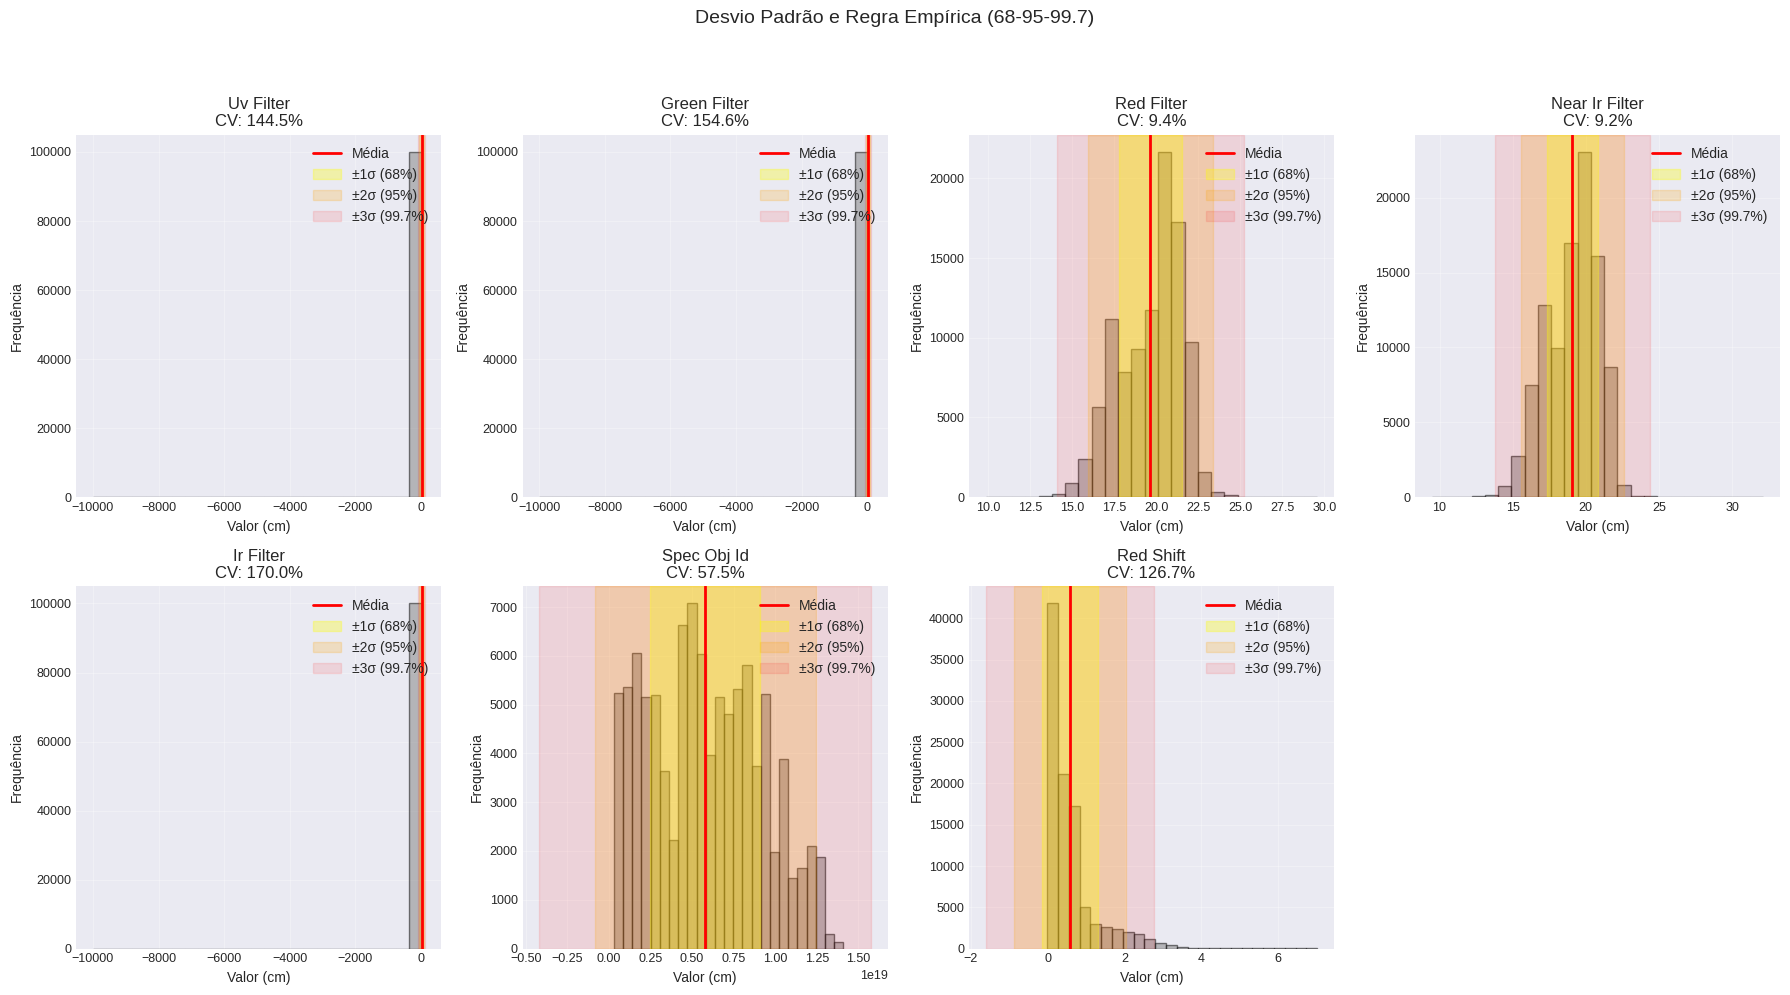

In [ ]:
#Medidas de dispersão
print("MEDIDAS DE DISPERSÃO")
print("=" * 40)

for feature in features:
    amplitude = stellar_classification[feature].max() - stellar_classification[feature].min()
    variancia = stellar_classification[feature].var()
    desvio_padrao = stellar_classification[feature].std()
    coef_variacao = (desvio_padrao / stellar_classification[feature].mean()) * 100

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Amplitude:           {amplitude:.3f}")
    print(f"  Variância:           {variancia:.3f}")
    print(f"  Desvio Padrão:       {desvio_padrao:.3f}")
    print(f"  Coef. de Variação:   {coef_variacao:.1f}%")


# Visualização do conceito de desvio padrão
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(18, 10))
fig.suptitle('Desvio Padrão e Regra Empírica (68-95-99.7)', fontsize=14, y=1.02)

# "achata" os eixos para iterar facilmente
axes = axes.flatten()

for idx, feature in enumerate(features):
    # Only plot if there are enough axes for the feature
    if idx < len(axes):
        ax = axes[idx]
        mean = stellar_classification[feature].mean()
        std = stellar_classification[feature].std()
        cv = (std/mean) * 100

        # Histograma
        counts, bins, patches = ax.hist(stellar_classification[feature], bins=25, alpha=0.5, color='gray', edgecolor='black')

        # Linha da média
        ax.axvline(mean, color='red', linewidth=2, label='Média', zorder=5)

        # Faixas de desvio padrão
        ax.axvspan(mean-std, mean+std, alpha=0.3, color='yellow', label='±1σ (68%)', zorder=3)
        ax.axvspan(mean-2*std, mean+2*std, alpha=0.2, color='orange', label='±2σ (95%)', zorder=2)
        ax.axvspan(mean-3*std, mean+3*std, alpha=0.1, color='red', label='±3σ (99.7%)', zorder=1)

        ax.set_title(f'{feature.replace("_", " ").title()}\nCV: {cv:.1f}%')
        ax.set_xlabel('Valor (cm)')
        ax.set_ylabel('Frequência')
        ax.legend(fontsize=10, loc='upper right')
        ax.grid(True, alpha=0.3)

# Remove any unused subplots if the number of features is less than the total subplots
for i in range(len(features), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

In [ ]:
# Calculando coeficiente de variação por classe estelar
print("COEFICIENTE DE VARIAÇÃO (%) POR CLASSE ESTELAR")
print("=" * 45)

cv_df = pd.DataFrame(index=features)

for stellar_class in stellar_classification['class'].unique():
    subset = stellar_classification[stellar_classification['class'] == stellar_class]
    cv_values = {}

    for feature in features:
        mean = subset[feature].mean()
        std = subset[feature].std()
        # Handle cases where mean might be zero or very close to zero to avoid division by zero or large CVs due to tiny means
        cv = (std / mean) * 100 if mean != 0 else np.nan  # CV em porcentagem
        cv_values[feature] = cv

    cv_df[stellar_class] = pd.Series(cv_values)

display(cv_df.round(2))

print("\nINTERPRETAÇÃO:")
print("- CV < 10%:  Baixa variabilidade")
print("- CV 10-20%: Média variabilidade")
print("- CV > 20%:  Alta variabilidade")

COEFICIENTE DE VARIAÇÃO (%) POR CLASSE ESTELAR


,GALAXY,QSO,STAR
UV_filter,10.02,6.94,329.77
green_filter,10.08,5.56,356.13
red_filter,9.57,5.26,10.41
near_IR_filter,8.96,5.29,9.93
IR_filter,8.98,5.40,381.60
spec_obj_ID,58.70,40.21,62.77
red_shift,62.82,53.15,-404.84



INTERPRETAÇÃO:
- CV < 10%:  Baixa variabilidade
- CV 10-20%: Média variabilidade
- CV > 20%:  Alta variabilidade


In [ ]:
print("MEDIDAS DE POSIÇÃO")
print("=" * 40)

for feature in features:
    q1 = stellar_classification[feature].quantile(0.25)
    q2 = stellar_classification[feature].quantile(0.50)  # mediana
    q3 = stellar_classification[feature].quantile(0.75)
    iqr = q3 - q1

    p10 = stellar_classification[feature].quantile(0.10)
    p90 = stellar_classification[feature].quantile(0.90)

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Q1 (25%):     {q1:.3f}")
    print(f"  Q2 (50%):     {q2:.3f}")
    print(f"  Q3 (75%):     {q3:.3f}")
    print(f"  IQR (Q3-Q1): {iqr:.3f}")
    print(f"  P10:          {p10:.3f}")
    print(f"  P90:          {p90:.3f}")

MEDIDAS DE POSIÇÃO

Uv Filter:
  Q1 (25%):     20.352
  Q2 (50%):     22.179
  Q3 (75%):     23.687
  IQR (Q3-Q1): 3.335
  P10:          19.117
  P90:          25.096

Green Filter:
  Q1 (25%):     18.965
  Q2 (50%):     21.100
  Q3 (75%):     22.124
  IQR (Q3-Q1): 3.159
  P10:          17.758
  P90:          22.892

Red Filter:
  Q1 (25%):     18.136
  Q2 (50%):     20.125
  Q3 (75%):     21.045
  IQR (Q3-Q1): 2.909
  P10:          17.010
  P90:          21.763

Near Ir Filter:
  Q1 (25%):     17.732
  Q2 (50%):     19.405
  Q3 (75%):     20.396
  IQR (Q3-Q1): 2.664
  P10:          16.619
  P90:          21.236

Ir Filter:
  Q1 (25%):     17.461
  Q2 (50%):     19.005
  Q3 (75%):     19.921
  IQR (Q3-Q1): 2.460
  P10:          16.342
  P90:          21.008

Spec Obj Id:
  Q1 (25%):     2840000000000000000.000
  Q2 (50%):     5610000000000000000.000
  Q3 (75%):     8330000000000000000.000
  IQR (Q3-Q1): 5490000000000000000.000
  P10:          1320000000000000000.000
  P90:          104

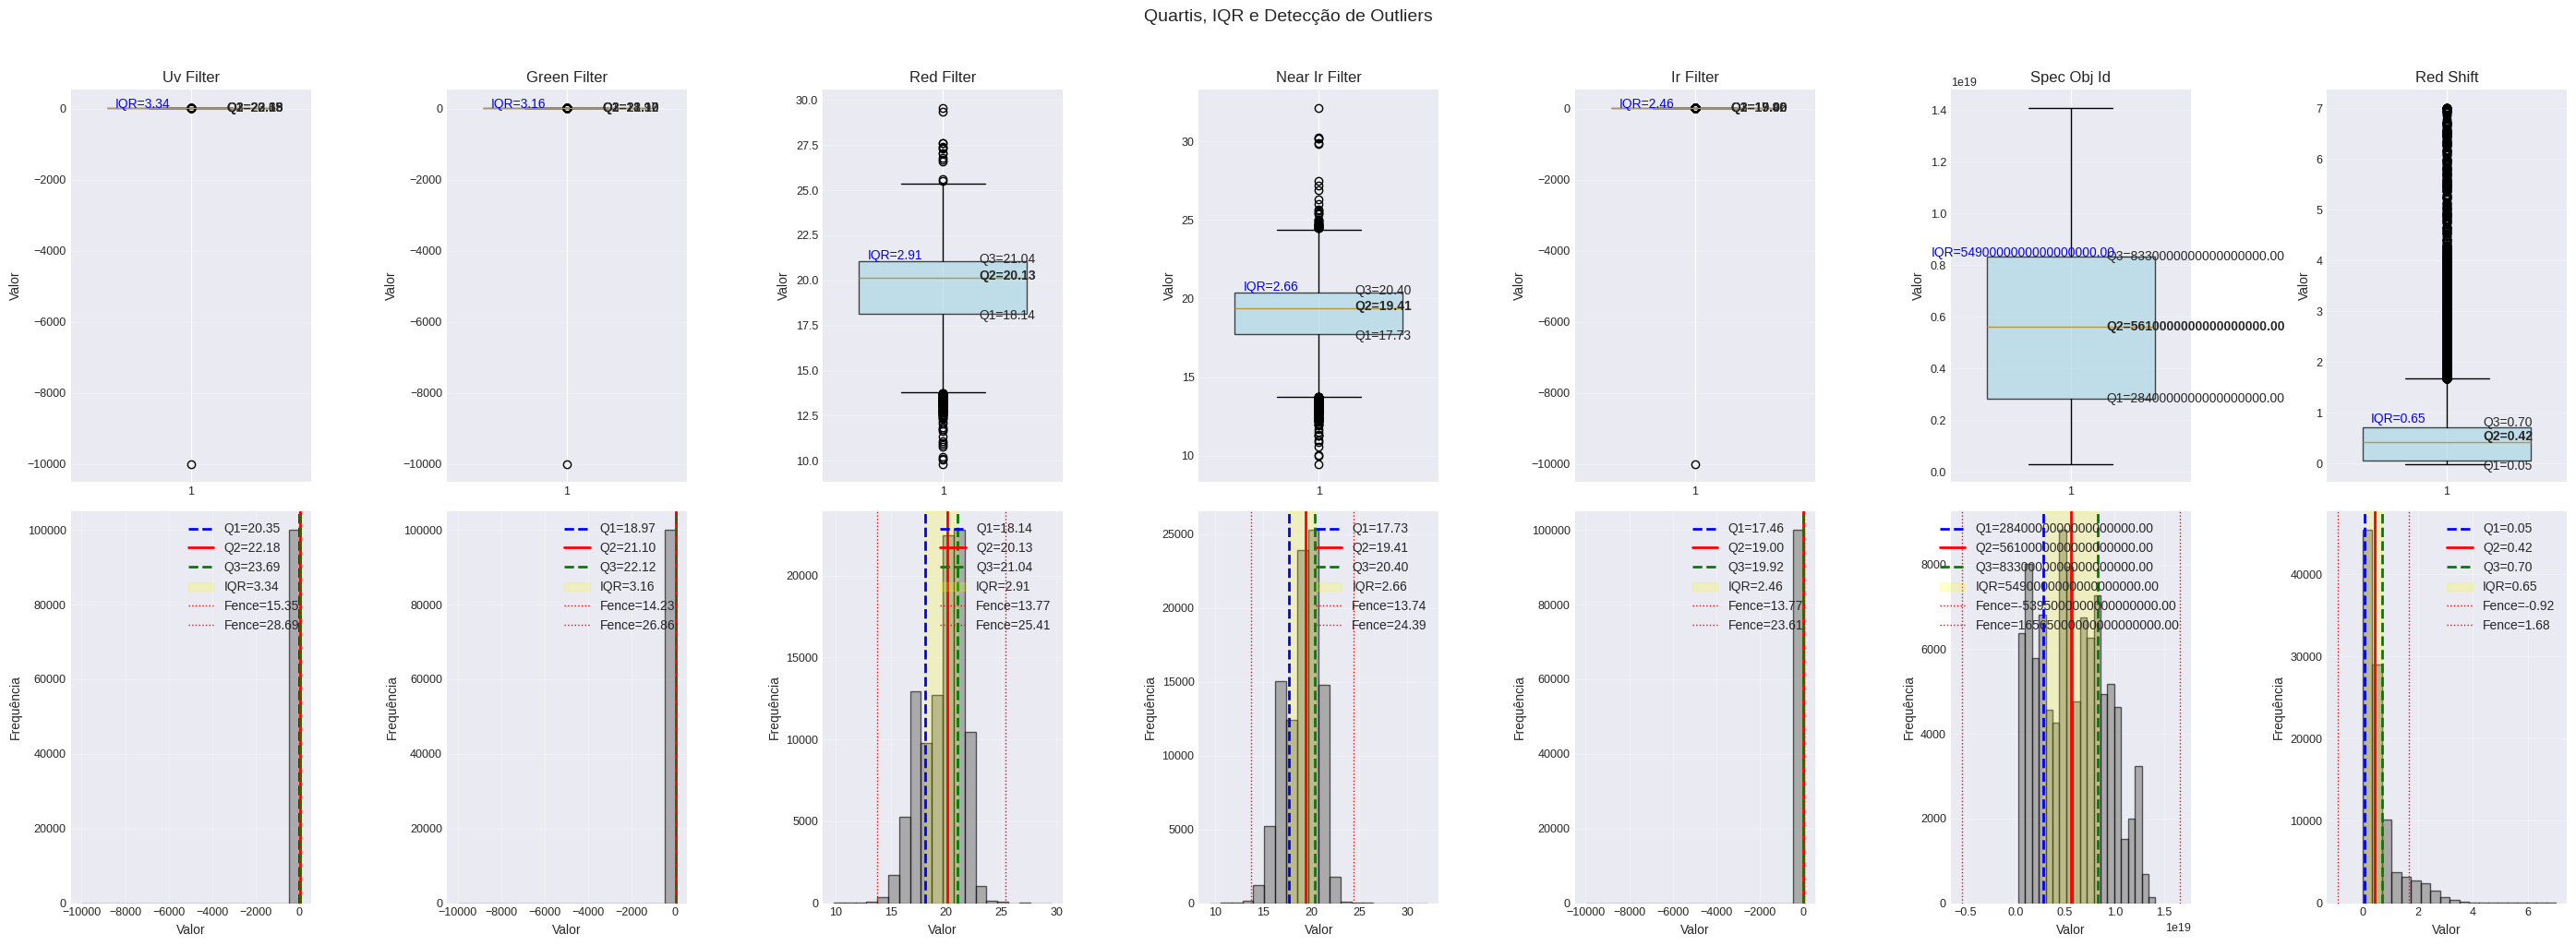

📊 COMPREENDENDO BOXPLOTS:
• Caixa central: IQR (50% central dos dados)
• Linha na caixa: Mediana (Q2)
• Bigodes: Até 1.5×IQR ou valor máximo/mínimo
• Pontos além dos bigodes: Possíveis outliers
• Linhas pontilhadas vermelhas (fence): Limites para detecção de outliers


In [ ]:
# Visualização de Quartis e IQR
# Adjusted ncols to len(features) to accommodate all plots
# Adjusted figsize for better visual appeal with more columns
fig, axes = plt.subplots(2, len(features), figsize=(28, 10))
fig.suptitle('Quartis, IQR e Detecção de Outliers', fontsize=14, y=1.02)

for idx, feature in enumerate(features):
    # Boxplot com anotações
    ax1 = axes[0, idx]
    bp = ax1.boxplot(stellar_classification[feature], vert=True, patch_artist=True, widths=0.7)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)

    # Calcular quartis
    q1, q2, q3 = stellar_classification[feature].quantile([0.25, 0.5, 0.75])
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr

    # Adicionar anotações
    ax1.text(1.15, q1-0.1, f'Q1={q1:.2f}', va='center', fontsize=10)
    ax1.text(1.15, q2+0.1, f'Q2={q2:.2f}', va='center', fontsize=10, fontweight='bold')
    ax1.text(1.15, q3+0.1, f'Q3={q3:.2f}', va='center', fontsize=10)
    ax1.text(0.8, q3 +0.1, f'IQR={iqr:.2f}', ha='center', fontsize=10, color='blue')

    ax1.set_title(feature.replace('_', ' ').title())
    # Removed '(cm)' as it is not appropriate for these features
    ax1.set_ylabel('Valor')
    ax1.grid(True, alpha=0.3, axis='y')

    # Histograma com quartis
    ax2 = axes[1, idx]
    ax2.hist(stellar_classification[feature], bins=20, alpha=0.6, color='gray', edgecolor='black')

    # Linhas dos quartis
    ax2.axvline(q1, color='blue', linestyle='--', linewidth=2, label=f'Q1={q1:.2f}')
    ax2.axvline(q2, color='red', linestyle='-', linewidth=2, label=f'Q2={q2:.2f}')
    ax2.axvline(q3, color='green', linestyle='--', linewidth=2, label=f'Q3={q3:.2f}')

    # Área do IQR
    ax2.axvspan(q1, q3, alpha=0.2, color='yellow', label=f'IQR={iqr:.2f}')

    # Limites de outliers (fence)
    ax2.axvline(lower_fence, color='red', linestyle=':', linewidth=1, label=f'Fence={lower_fence:.2f}')
    ax2.axvline(upper_fence, color='red', linestyle=':', linewidth=1, label=f'Fence={upper_fence:.2f}')

    # Removed '(cm)' as it is not appropriate for these features
    ax2.set_xlabel('Valor')
    ax2.set_ylabel('Frequência')
    ax2.legend(fontsize=10, loc='upper right')
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("📊 COMPREENDENDO BOXPLOTS:")
print("• Caixa central: IQR (50% central dos dados)")
print("• Linha na caixa: Mediana (Q2)")
print("• Bigodes: Até 1.5×IQR ou valor máximo/mínimo")
print("• Pontos além dos bigodes: Possíveis outliers")
print("• Linhas pontilhadas vermelhas (fence): Limites para detecção de outliers")


In [ ]:
# Estatísticas descritivas por classe estelar
print("ESTATÍSTICAS POR CLASSE ESTELAR")
print("=" * 50)

stats_by_class = stellar_classification.groupby('class').describe()
display(stats_by_class)

print("\nMÉDIAS POR CLASSE ESTELAR:")
means_by_class = stellar_classification.groupby('class')[features].mean()
display(means_by_class.round(3))

ESTATÍSTICAS POR CLASSE ESTELAR


object_ID                                                           \
           count          mean            std           min           25%   
class                                                                       
GALAXY   59445.0  1.240000e+18  253698.133899  1.240000e+18  1.240000e+18   
QSO      18961.0  1.240000e+18  235782.217640  1.240000e+18  1.240000e+18   
STAR     21594.0  1.240000e+18  239109.536545  1.240000e+18  1.240000e+18   

                                                    delta             \
                 50%           75%           max    count       mean   
class                                                                  
GALAXY  1.240000e+18  1.240000e+18  1.240000e+18  59444.0  23.513961   
QSO     1.240000e+18  1.240000e+18  1.240000e+18  18960.0  26.806728   
STAR    1.240000e+18  1.240000e+18  1.240000e+18  21594.0  23.498554   

                                                                         \
              std        min       25%        50%        75%        max   
class                                                                     
GALAXY  19.315364 -12.364701  5.167008  22.302185  37.972984  77.615588   
QSO     19.587192 -15.980904  7.426132  29.294346  42.886555  82.288657   
STAR    20.383288 -18.785328  3.127855  23.400565  39.939705  83.000519   

       UV_filter                                                          \
           count       mean        std         min        25%        50%   
class                                                                      
GALAXY   59445.0  22.587379   2.264355    13.89799  20.794760  22.841770   
QSO      18961.0  21.547619   1.495879    10.99623  20.637640  21.503240   
STAR     21594.0  20.689805  68.228825 -9999.00000  19.327275  21.010555   

                            green_filter                                    \
              75%       max        count       mean        std         min   
class                                                                        
GALAXY  24.207410  29.32565      59445.0  20.906101   2.107755    12.67902   
QSO     22.286470  32.78139      18961.0  20.926193   1.163239    13.66217   
STAR    22.960617  30.66039      21594.0  19.153188  68.210460 -9999.00000   

                                                 red_filter             \
              25%        50%       75%       max      count       mean   
class                                                                    
GALAXY  18.912680  21.582200  22.44513  31.60224    59445.0  19.587552   
QSO     20.249730  21.056290  21.68777  27.89482    18961.0  20.624089   
STAR    18.034847  19.542825  21.22869  30.60700    21594.0  18.946969   

                                                                      \
             std       min        25%       50%        75%       max   
class                                                                  
GALAXY  1.874133  11.74664  17.817150  20.10459  20.974610  29.57186   
QSO     1.084237  12.35763  20.006330  20.77272  21.413450  27.39709   
STAR    1.972786   9.82207  17.454012  18.95508  20.557477  29.37411   

       near_IR_filter                                                       \
                count       mean       std        min        25%       50%   
class                                                                        
GALAXY        59445.0  18.851990  1.689809  11.299560  17.379670  19.22366   
QSO           18961.0  20.431173  1.080135  12.637440  19.811070  20.58211   
STAR          21594.0  18.543736  1.841714   9.469903  17.139703  18.59236   

                           IR_filter                                    \
             75%       max     count       mean        std         min   
class                                                                    
GALAXY  19.94709  30.16359   59445.0  18.449156   1.656302    10.89738   
QSO     21.20228  32.14147   18961.0  20.266732   1.095076    11.30247   
STAR    20.04169 


MÉDIAS POR CLASSE ESTELAR:


,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,spec_obj_ID,red_shift
class,,,,,,,
GALAXY,22.587,20.906,19.588,18.852,18.449,5.482932e+18,0.422
QSO,21.548,20.926,20.624,20.431,20.267,7.816585e+18,1.720
STAR,20.690,19.153,18.947,18.544,17.870,4.827698e+18,-0.000


In [ ]:
# Calculando matriz de correlação
correlation_matrix = stellar_classification[features].corr()

print("MATRIZ DE CORRELAÇÃO (Pearson)")
print("=" * 40)
display(correlation_matrix.round(3))

# Identificando correlações mais fortes
print("\nCORRELAÇÕES MAIS FORTES:")
print("-" * 30)

# Extrair pares únicos (triangular superior)
mask = np.triu(np.ones_like(correlation_matrix), k=1).astype(bool)
correlations = correlation_matrix.where(mask).stack().reset_index()
correlations.columns = ['Var1', 'Var2', 'Correlacao']
correlations = correlations.sort_values('Correlacao', key=abs, ascending=False)

for _, row in correlations.head(5).iterrows():
    print(f"{row['Var1']} vs {row['Var2']}: {row['Correlacao']:.3f}")

MATRIZ DE CORRELAÇÃO (Pearson)


,UV_filter,green_filter,red_filter,near_IR_filter,IR_filter,spec_obj_ID,red_shift
UV_filter,1.000,0.999,0.054,0.046,0.998,0.030,0.014
green_filter,0.999,1.000,0.062,0.056,0.999,0.039,0.023
red_filter,0.054,0.062,1.000,0.963,0.054,0.655,0.433
near_IR_filter,0.046,0.056,0.963,1.000,0.056,0.662,0.492
IR_filter,0.998,0.999,0.054,0.056,1.000,0.038,0.030
spec_obj_ID,0.030,0.039,0.655,0.662,0.038,1.000,0.389
red_shift,0.014,0.023,0.433,0.492,0.030,0.389,1.000



CORRELAÇÕES MAIS FORTES:
------------------------------
UV_filter vs green_filter: 0.999
green_filter vs IR_filter: 0.999
UV_filter vs IR_filter: 0.998
red_filter vs near_IR_filter: 0.963
near_IR_filter vs spec_obj_ID: 0.662


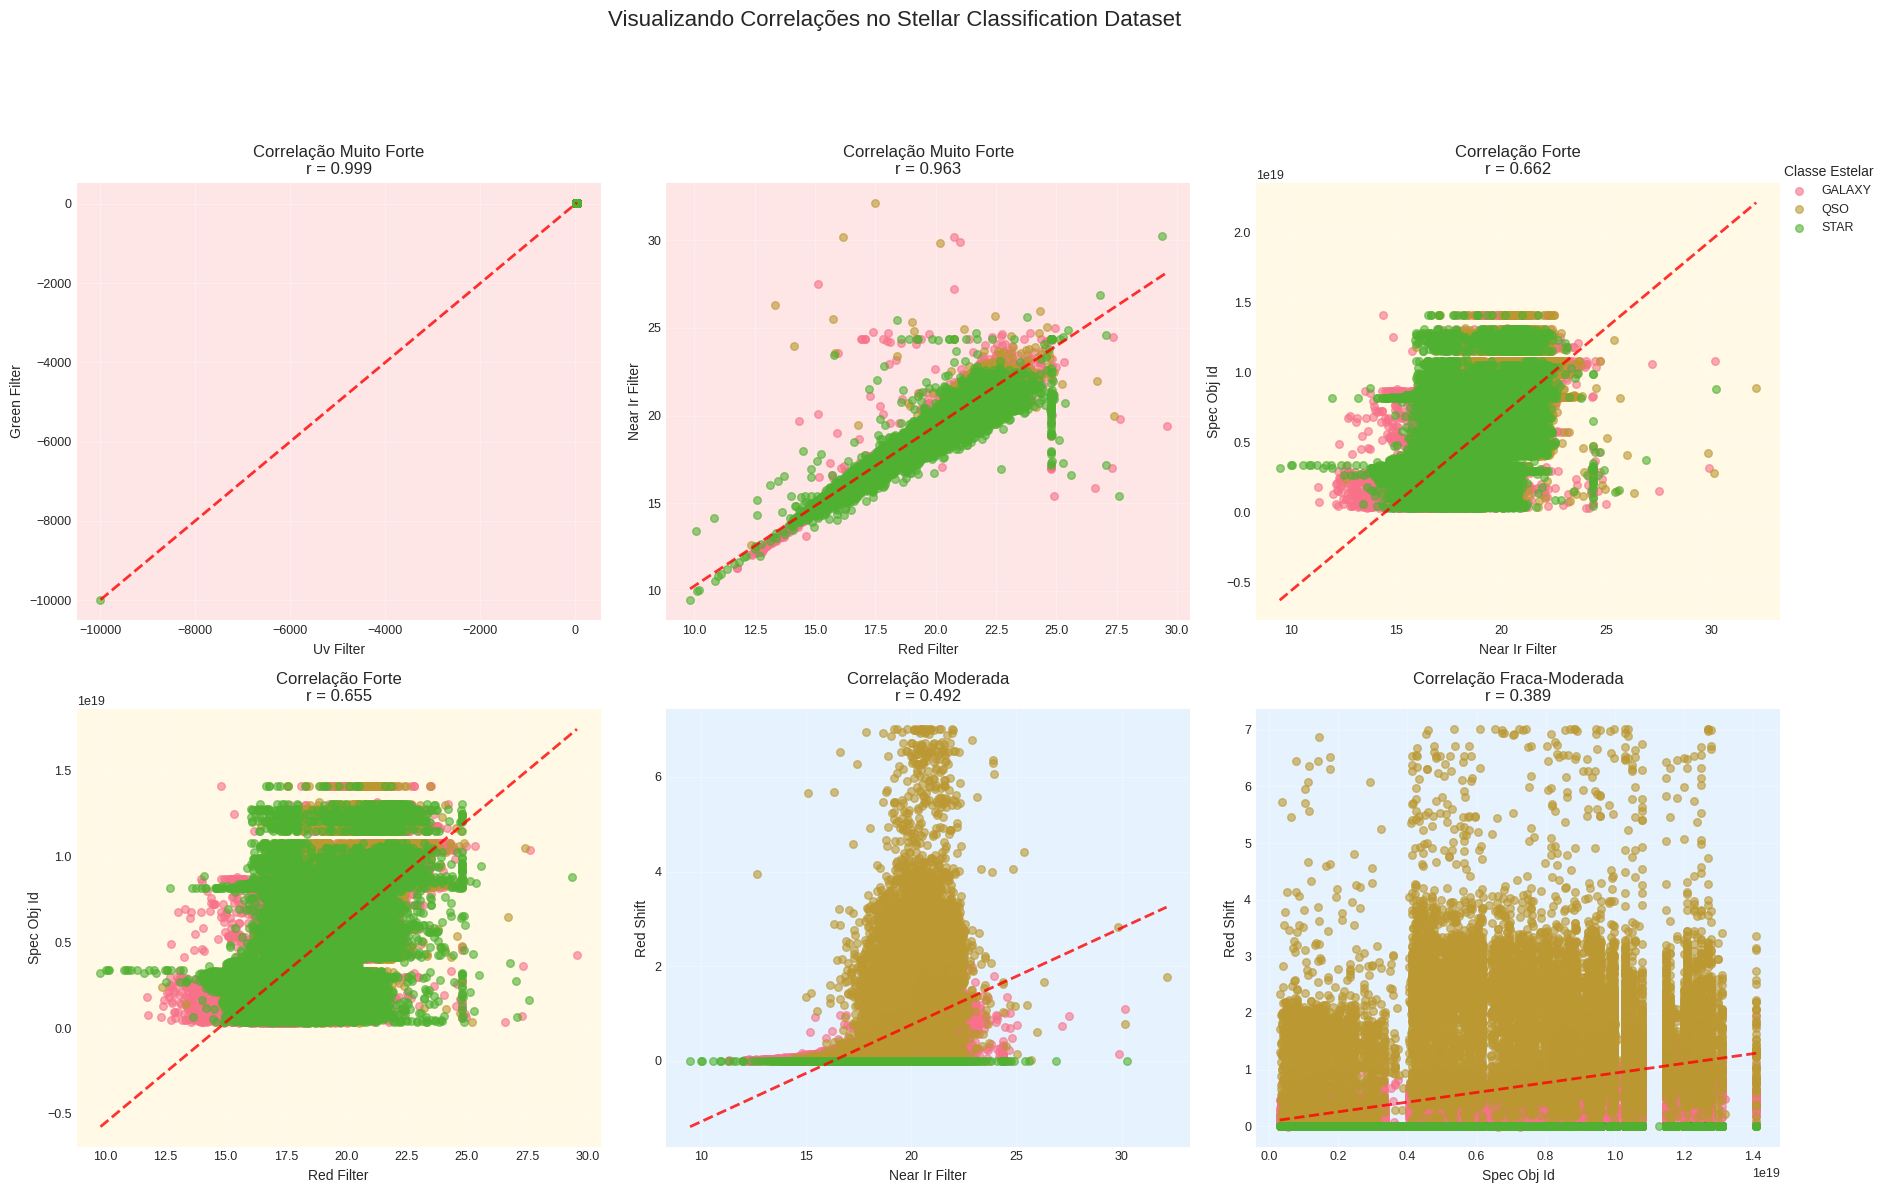

In [ ]:

# Visualização de diferentes níveis de correlação para stellar_classification
fig, axes = plt.subplots(2, 3, figsize=(18, 12)) # Adjusted figsize for better visibility
fig.suptitle('Visualizando Correlações no Stellar Classification Dataset', fontsize=16, y=1.02)

# Exemplos de correlações baseadas na análise anterior
# Choosing 6 diverse correlations from the previous analysis:
# UV_filter vs green_filter: 0.999 (Very Strong)
# red_filter vs near_IR_filter: 0.963 (Very Strong)
# near_IR_filter vs spec_obj_ID: 0.662 (Strong)
# red_filter vs spec_obj_ID: 0.655 (Strong)
# near_IR_filter vs red_shift: 0.492 (Moderate)
# spec_obj_ID vs red_shift: 0.389 (Weak-Moderate)

correlations_to_plot = [
    ('UV_filter', 'green_filter', 'Correlação Muito Forte'),
    ('red_filter', 'near_IR_filter', 'Correlação Muito Forte'),
    ('near_IR_filter', 'spec_obj_ID', 'Correlação Forte'),
    ('red_filter', 'spec_obj_ID', 'Correlação Forte'),
    ('near_IR_filter', 'red_shift', 'Correlação Moderada'),
    ('spec_obj_ID', 'red_shift', 'Correlação Fraca-Moderada')
]

# Flatten the axes for easy iteration
axes = axes.flatten()

for idx, (x_var, y_var, title) in enumerate(correlations_to_plot):
    ax = axes[idx]

    # Calcular correlação
    # Ensure non-numeric values are handled, though the features list is numeric.
    # For simplicity, we'll assume these columns are clean after initial EDA for correlation calculation.
    corr_value = stellar_classification[x_var].corr(stellar_classification[y_var])

    # Scatter plot com cores por classe estelar
    for stellar_class in stellar_classification['class'].unique():
        subset = stellar_classification[stellar_classification['class'] == stellar_class]
        ax.scatter(subset[x_var], subset[y_var], alpha=0.6, s=30, label=stellar_class)

    # Linha de tendência geral
    # Using only non-NaN values for polyfit to avoid issues
    valid_data = stellar_classification[[x_var, y_var]].dropna()
    if not valid_data.empty:
        z = np.polyfit(valid_data[x_var], valid_data[y_var], 1)
        p = np.poly1d(z)
        x_line = np.linspace(valid_data[x_var].min(), valid_data[x_var].max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)

    ax.set_xlabel(x_var.replace('_', ' ').title())
    ax.set_ylabel(y_var.replace('_', ' ').title())
    ax.set_title(f'{title}\nr = {corr_value:.3f}')
    ax.grid(True, alpha=0.3)

    # Colorir o fundo baseado na força da correlação
    if abs(corr_value) > 0.8:
        ax.set_facecolor('#ffe6e6')  # Vermelho claro para forte
    elif abs(corr_value) > 0.5:
        ax.set_facecolor('#fff9e6')  # Amarelo claro para moderado
    else:
        ax.set_facecolor('#e6f3ff')  # Azul claro para fraco

# Adicionar legenda geral, placed outside the subplots to avoid overlap
handles, labels = axes[0].get_legend_handles_labels() # Get handles/labels from first subplot
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.05, 0.9), title='Classe Estelar')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap and accommodate legend
plt.show()


TESTE DE NORMALIDADE (Shapiro-Wilk)
H0: Os dados seguem uma distribuição normal
H1: Os dados NÃO seguem uma distribuição normal

Nível de significância: α = 0.05
---------------------------------------------

Uv Filter:
  Estatística: 0.0072
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Green Filter:
  Estatística: 0.0060
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Red Filter:
  Estatística: 0.9625
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Near Ir Filter:
  Estatística: 0.9770
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Ir Filter:
  Estatística: 0.0049
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Spec Obj Id:
  Estatística: 0.9685
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)

Red Shift:
  Estatística: 0.7403
  p-valor:     0.000000
  Conclusão:   ✗ Não-normal (rejeita H0)


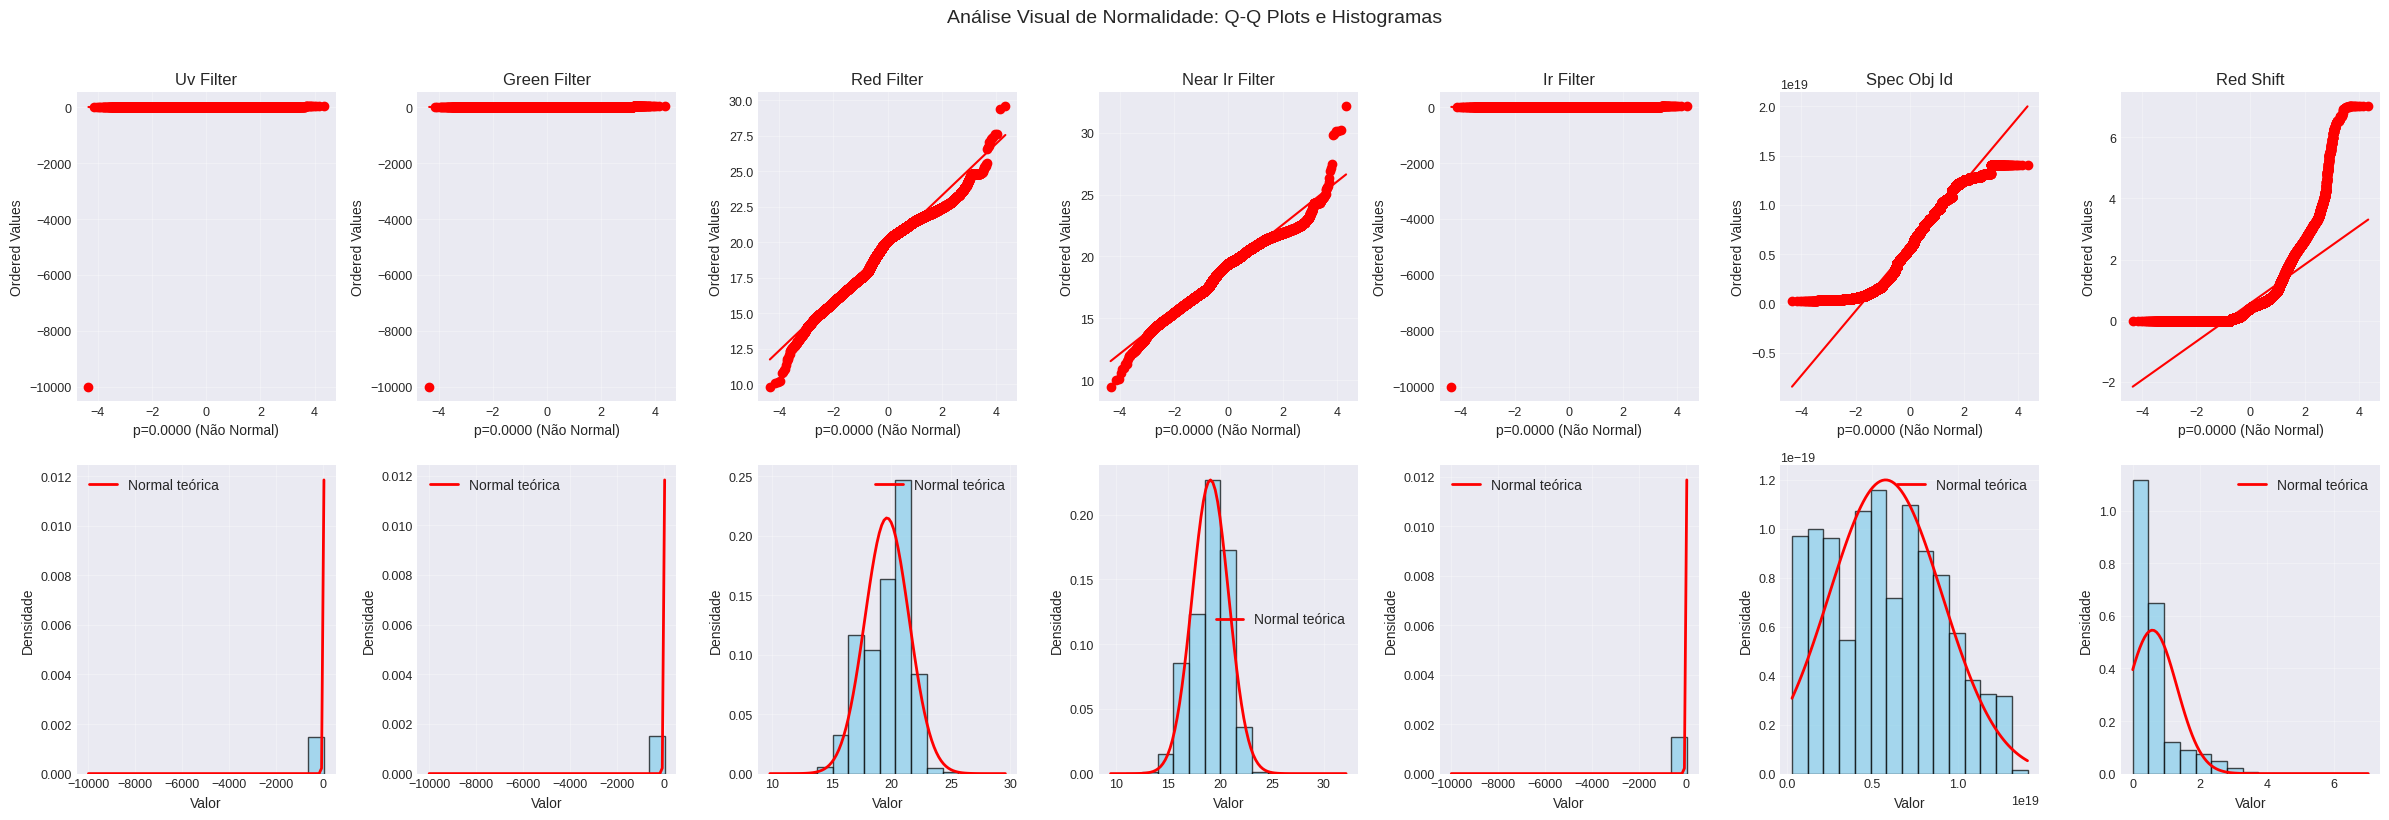

In [ ]:
# @title
# Teste de Shapiro-Wilk para normalidade
print("TESTE DE NORMALIDADE (Shapiro-Wilk)")
print("=" * 45)
print("H0: Os dados seguem uma distribuição normal")
print("H1: Os dados NÃO seguem uma distribuição normal")
print("\nNível de significância: α = 0.05")
print("-" * 45)

alpha = 0.05

for feature in features:
    stat, p_value = stats.shapiro(stellar_classification[feature])

    if p_value > alpha:
        conclusion = "✓ Normal (falha em rejeitar H0)"
    else:
        conclusion = "✗ Não-normal (rejeita H0)"

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  Estatística: {stat:.4f}")
    print(f"  p-valor:     {p_value:.6f}")
    print(f"  Conclusão:   {conclusion}")

# Visualização de normalidade com Q-Q plots
# Changed ncols to len(features) to accommodate all features
fig, axes = plt.subplots(2, len(features), figsize=(24, 8)) # Adjusted figsize for better visibility with more columns
fig.suptitle('Análise Visual de Normalidade: Q-Q Plots e Histogramas', fontsize=14, y=1.02)

for idx, feature in enumerate(features):
    # Q-Q plot
    ax1 = axes[0, idx]
    stats.probplot(stellar_classification[feature], dist="norm", plot=ax1)
    ax1.set_title(f'{feature.replace("_", " ").title()}')
    ax1.grid(True, alpha=0.3)

    # Obter p-valor do teste Shapiro-Wilk
    _, p_value = stats.shapiro(stellar_classification[feature])

    # Adicionar interpretação no título
    if p_value > 0.05:
        ax1.set_xlabel(f'p={p_value:.4f} (Normal)', fontsize=10)
        ax1.get_lines()[0].set_color('green')
    else:
        ax1.set_xlabel(f'p={p_value:.4f} (Não Normal)', fontsize=10)
        ax1.get_lines()[0].set_color('red')

    # Histograma com curva normal teórica
    ax2 = axes[1, idx]

    # Histograma dos dados reais
    n, bins, patches = ax2.hist(stellar_classification[feature], bins=15, density=True,
                                alpha=0.7, color='skyblue', edgecolor='black')

    # Curva normal teórica
    mu = stellar_classification[feature].mean()
    sigma = stellar_classification[feature].std()
    x = np.linspace(stellar_classification[feature].min(), stellar_classification[feature].max(), 100)
    ax2.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2,
            label='Normal teórica')

    ax2.set_xlabel('Valor') # Changed from 'Valor (cm)' to 'Valor'
    ax2.set_ylabel('Densidade') # Kept 'Densidade' as it is appropriate for density histograms
    ax2.legend(fontsize=10)
    ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

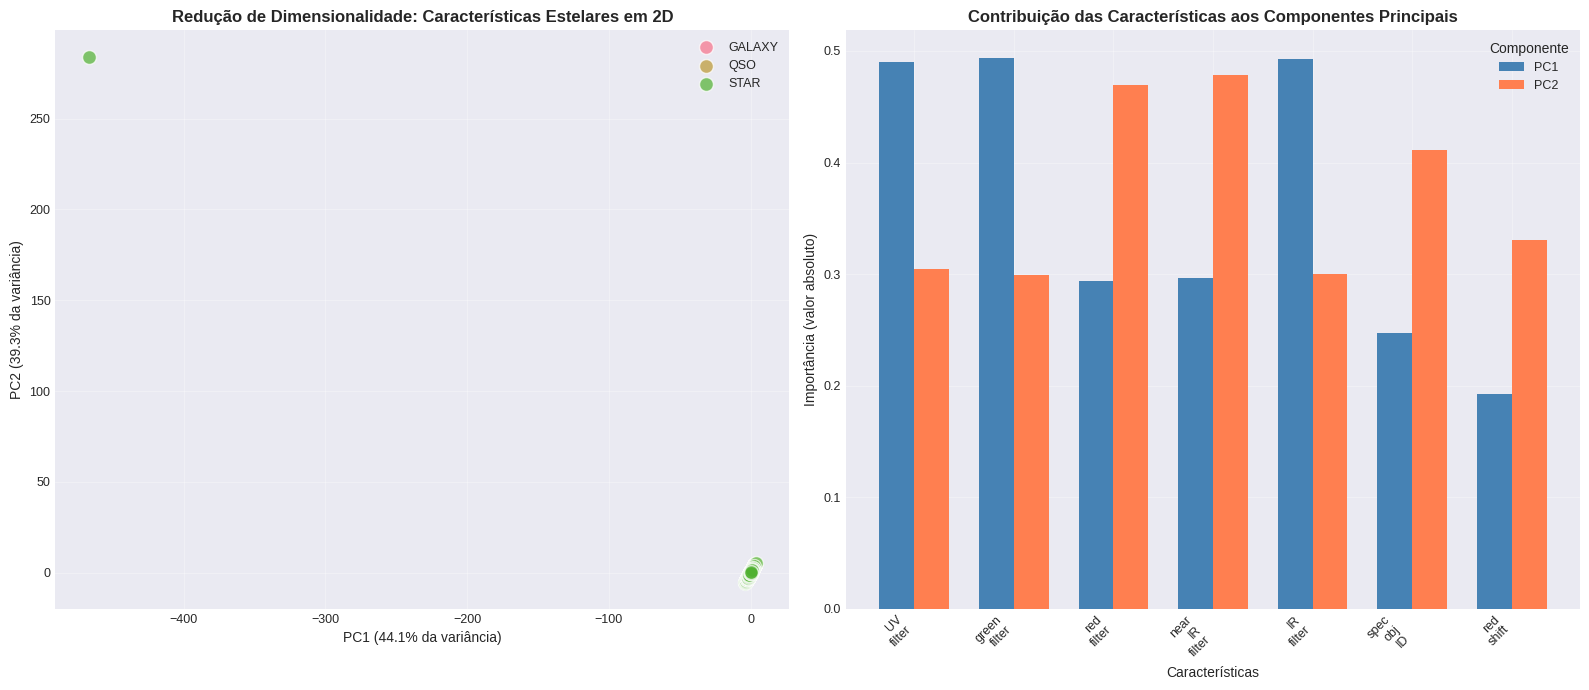

📊 ANÁLISE DE PADRÕES:
• Variância explicada pelos 2 primeiros componentes: 83.5%
• PC1 e PC2 capturam as principais fontes de variação nos dados estelares.
• A separação visual entre as classes estelares (GALAXY, QSO, STAR) é aparente, indicando que o PCA pode ser útil para visualização e, potencialmente, para modelos de classificação.

📈 Contribuições das características para cada Componente Principal:
  Uv Filter:
    PC1: 0.491
    PC2: 0.305
  Green Filter:
    PC1: 0.494
    PC2: 0.299
  Red Filter:
    PC1: 0.294
    PC2: 0.469
  Near Ir Filter:
    PC1: 0.296
    PC2: 0.479
  Ir Filter:
    PC1: 0.493
    PC2: 0.300
  Spec Obj Id:
    PC1: 0.247
    PC2: 0.411
  Red Shift:
    PC1: 0.193
    PC2: 0.330


In [ ]:
# Padronizando os dados
scaler = StandardScaler()
X_scaled = scaler.fit_transform(stellar_classification[features])

# Aplicando PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Criando DataFrame com componentes principais
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['class'] = stellar_classification['class'].values

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Subplot 1: PCA scatter
ax1 = axes[0]
for stellar_class in stellar_classification['class'].unique():
    subset = pca_df[pca_df['class'] == stellar_class]
    ax1.scatter(subset['PC1'], subset['PC2'],
               label=stellar_class, alpha=0.7, s=100, edgecolors='white')

ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} da variância)')
ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} da variância)')
ax1.set_title('Redução de Dimensionalidade: Características Estelares em 2D', fontsize=12, weight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Subplot 2: Importância das características
ax2 = axes[1]
components = pd.DataFrame(
    pca.components_.T,
    columns=['PC1', 'PC2'],
    index=features
)
components_abs = components.abs()

# Criando o gráfico de barras manualmente
x = np.arange(len(features))
width = 0.35

bars1 = ax2.bar(x - width/2, components_abs['PC1'], width, label='PC1', color='steelblue')
bars2 = ax2.bar(x + width/2, components_abs['PC2'], width, label='PC2', color='coral')

ax2.set_xlabel('Características')
ax2.set_ylabel('Importância (valor absoluto)')
ax2.set_title('Contribuição das Características aos Componentes Principais', fontsize=12, weight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f.replace('_', '\n') for f in features], rotation=45, ha='right')
ax2.legend(title='Componente')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"📊 ANÁLISE DE PADRÕES:")
print(f"• Variância explicada pelos 2 primeiros componentes: {sum(pca.explained_variance_ratio_):.1%}")
print(f"• PC1 e PC2 capturam as principais fontes de variação nos dados estelares.")
print(f"• A separação visual entre as classes estelares (GALAXY, QSO, STAR) é aparente, indicando que o PCA pode ser útil para visualização e, potencialmente, para modelos de classificação.")

# Mostrando os valores exatos das contribuições
print(f"\n📈 Contribuições das características para cada Componente Principal:")
for feature in features:
    print(f"  {feature.replace('_', ' ').title()}:")
    print(f"    PC1: {abs(components.loc[feature, 'PC1']):.3f}")
    print(f"    PC2: {abs(components.loc[feature, 'PC2']):.3f}")

ANOVA - ANÁLISE DE VARIÂNCIA
H0: Não há diferença entre as médias das classes estelares
H1: Pelo menos uma classe estelar tem média diferente

Nível de significância: α = 0.05
----------------------------------------

Uv Filter:
  F-estatística: 30.4453
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Green Filter:
  F-estatística: 25.9625
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Red Filter:
  F-estatística: 4584.5334
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Near Ir Filter:
  F-estatística: 8282.3435
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Ir Filter:
  F-estatística: 32.3283
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Spec Obj Id:
  F-estatística: 5166.0968
  p-valor:       0.00000000
  Conclusão:     ✓ Há diferença significativa (rejeita H0)

Red Shift:
  F-estatí

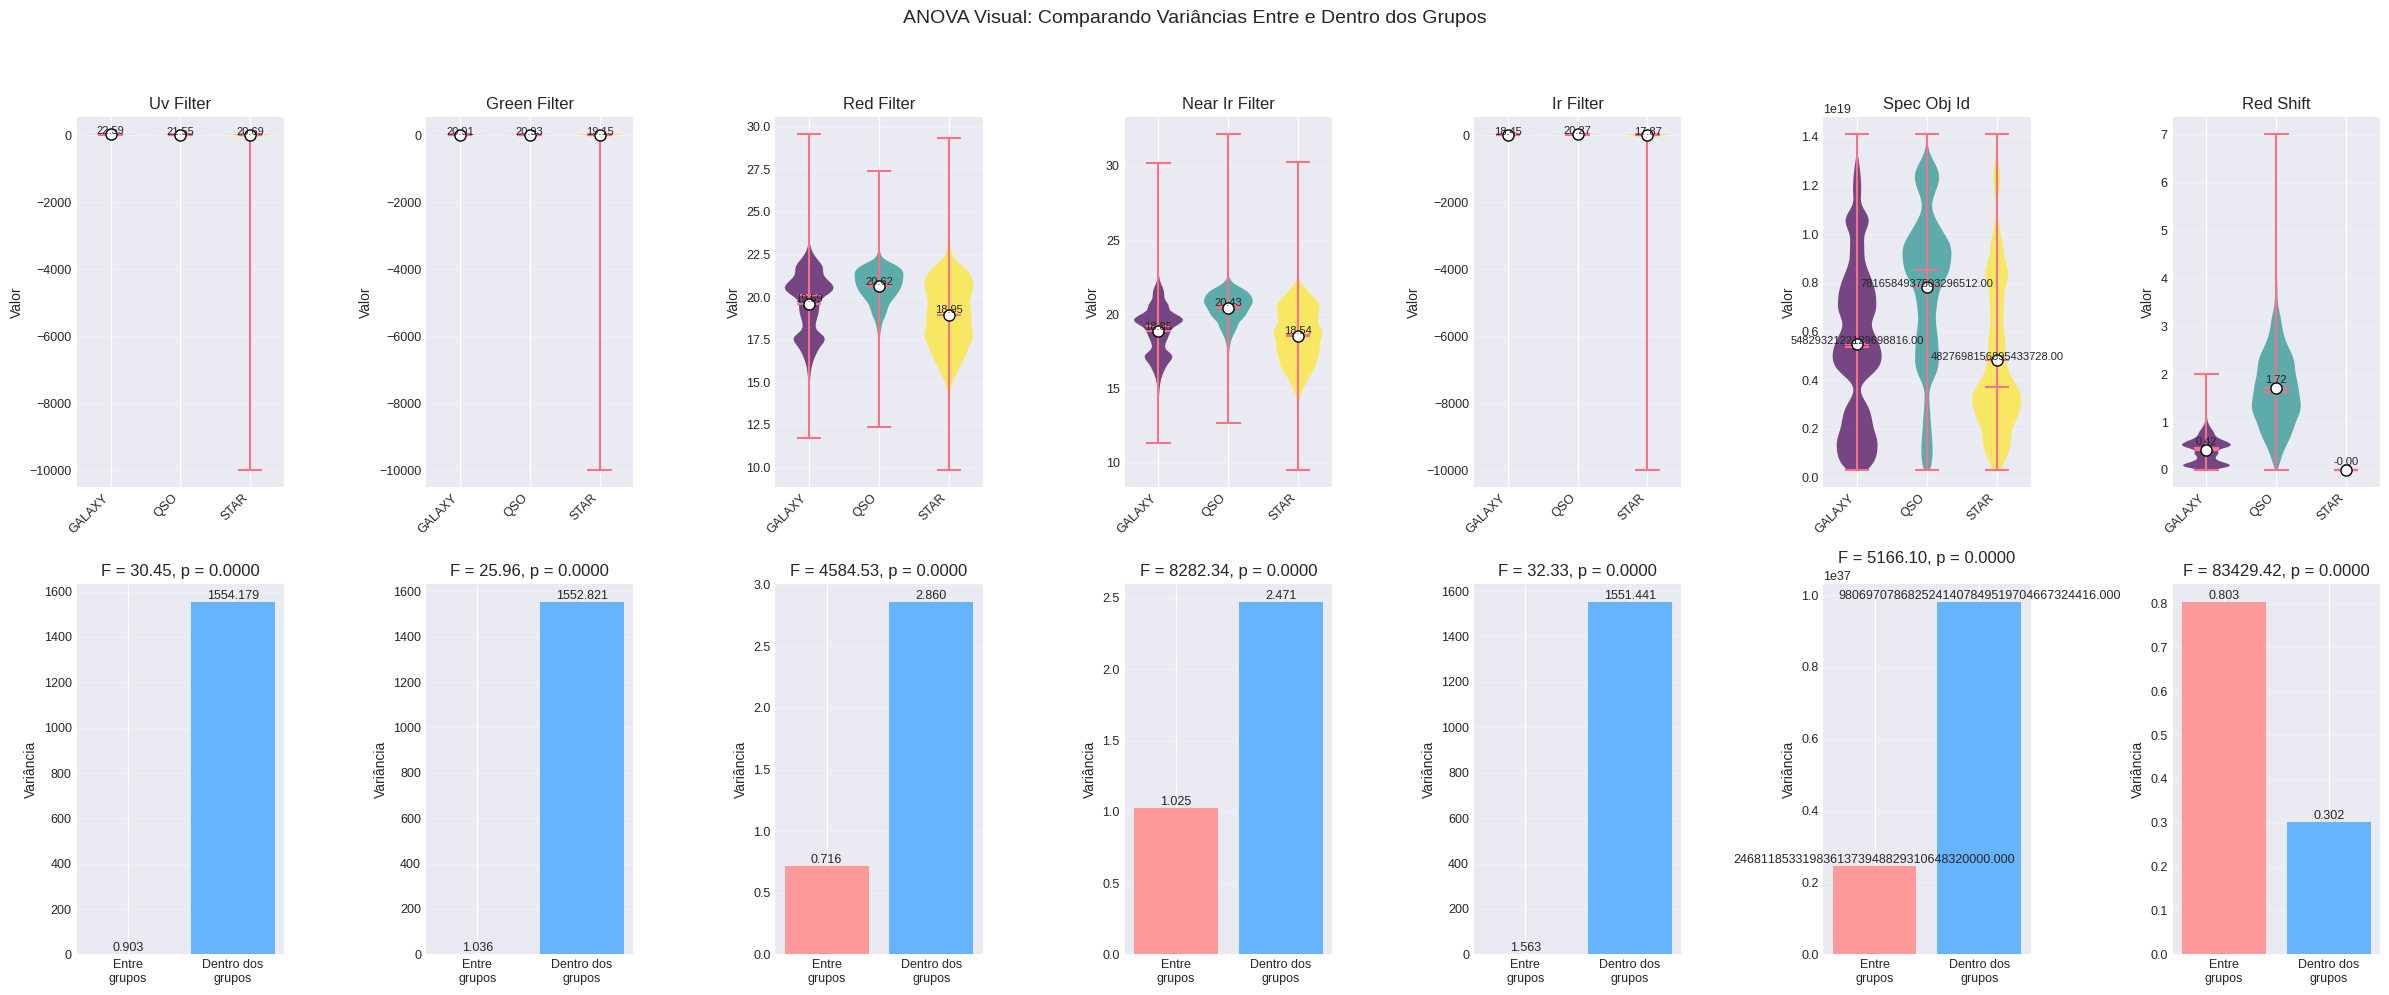

In [ ]:
# ANOVA para verificar diferenças entre classes estelares
print("ANOVA - ANÁLISE DE VARIÂNCIA")
print("=" * 40)
print("H0: Não há diferença entre as médias das classes estelares")
print("H1: Pelo menos uma classe estelar tem média diferente")
print("\nNível de significância: α = 0.05")
print("-" * 40)

alpha = 0.05

# Get unique stellar classes from the dataset
stellar_classes_unique = stellar_classification['class'].unique()

for feature in features:
    # Prepare groups for ANOVA based on actual stellar classes
    groups = [stellar_classification[stellar_classification['class'] == sc][feature].dropna() for sc in stellar_classes_unique]

    # Ensure there are at least two groups and that all groups are not empty
    if len(groups) < 2 or any(g.empty for g in groups):
        print(f"\n{feature.replace('_', ' ').title()}: Não há grupos suficientes ou grupos vazios para realizar ANOVA.")
        continue

    # Realizando ANOVA
    f_stat, p_value = stats.f_oneway(*groups)

    if p_value < alpha:
        conclusion = "✓ Há diferença significativa (rejeita H0)"
    else:
        conclusion = "✗ Sem diferença significativa (falha em rejeitar H0)"

    print(f"\n{feature.replace('_', ' ').title()}:")
    print(f"  F-estatística: {f_stat:.4f}")
    print(f"  p-valor:       {p_value:.8f}")
    print(f"  Conclusão:     {conclusion}")


# Visualização do conceito de ANOVA
# Adjust ncols to len(features) to accommodate all plots dynamically
fig, axes = plt.subplots(2, len(features), figsize=(24, 10)) # Adjusted figsize for better visibility
fig.suptitle('ANOVA Visual: Comparando Variâncias Entre e Dentro dos Grupos', fontsize=14, y=1.02)

# Flatten the axes array to easily iterate through them
axes = axes.flatten()

for idx, feature in enumerate(features):
    ax1 = axes[idx] if len(features) > 1 else axes[0] # Handle single feature case for axes
    ax2 = axes[idx + len(features)] if len(features) > 1 else axes[1] # Handle single feature case for axes

    # Prepare groups for plotting, ensuring they are not empty
    current_feature_groups_data = [stellar_classification[stellar_classification['class'] == sc][feature].dropna() for sc in stellar_classes_unique]
    valid_current_feature_groups_data = [g for g in current_feature_groups_data if not g.empty]
    valid_stellar_classes_for_plot = [sc for sc, g in zip(stellar_classes_unique, current_feature_groups_data) if not g.empty]

    if not valid_current_feature_groups_data:
        ax1.set_visible(False) # Hide subplot if no valid data
        ax2.set_visible(False)
        continue

    # Violin plot to show distributions by group
    positions = np.arange(len(valid_stellar_classes_for_plot))
    parts = ax1.violinplot(valid_current_feature_groups_data,
                           positions=positions,
                           widths=0.7,
                           showmeans=True,
                           showmedians=True)

    # Customize colors dynamically
    colors = plt.cm.viridis(np.linspace(0, 1, len(valid_stellar_classes_for_plot)))
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    # Add means as points
    for i, sc in enumerate(valid_stellar_classes_for_plot):
        mean_val = stellar_classification[stellar_classification['class'] == sc][feature].mean()
        ax1.plot(i, mean_val, 'o', color='white', markeredgecolor='black', markersize=8)
        ax1.text(i, mean_val + 0.1, f'{mean_val:.2f}', ha='center', fontsize=8)

    ax1.set_xticks(positions)
    ax1.set_xticklabels(valid_stellar_classes_for_plot, rotation=45, ha='right')
    ax1.set_title(feature.replace('_', ' ').title())
    ax1.set_ylabel('Valor') # Removed '(cm)'
    ax1.grid(True, alpha=0.3, axis='y')

    # Bar chart showing variances
    # Calculate variances directly for the current feature
    var_between = stellar_classification.groupby('class')[feature].mean().var() # Variance of group means
    var_within = stellar_classification.groupby('class')[feature].var().mean() # Mean of variances within groups

    # Get the F-statistic and p-value for the plot title
    f_stat_plot, p_value_plot = stats.f_oneway(*valid_current_feature_groups_data)

    bars = ax2.bar(['Entre\ngrupos', 'Dentro dos\ngrupos'],
                   [var_between, var_within],
                   color=['#ff9999', '#66b3ff'])

    # Add values on bars
    for bar, val in zip(bars, [var_between, var_within]):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

    ax2.set_title(f'F = {f_stat_plot:.2f}, p = {p_value_plot:.4f}')
    ax2.set_ylabel('Variância')
    ax2.grid(True, alpha=0.3, axis='y')

# Remove any unused subplots if the number of features is less than the total subplots
for i in range(len(features) * 2, len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent title overlap
plt.show()

In [ ]:
print("RESUMO DAS DESCOBERTAS ESTATÍSTICAS")
print("=" * 45)

print("\n📊 TENDÊNCIA CENTRAL:")
print("   - O teste ANOVA indicou diferenças significativas nas médias para todas as características entre as classes estelares (GALAXY, QSO, STAR).")
print("   - Observou-se que as características dos filtros (UV, green, red, near IR, IR) e `red_shift` variam consistentemente entre as classes, com GALAXY e QSO geralmente apresentando valores mais altos em alguns filtros e `red_shift` para QSO sendo notavelmente maior.")

print("\n📈 DISPERSÃO:")
print("   - Os coeficientes de variação (CV) mostraram grande variabilidade, com alguns filtros (UV, green, IR) e `spec_obj_ID` e `red_shift` apresentando CVs muito altos, especialmente para a classe STAR.")
print("   - Os filtros red_filter e near_IR_filter apresentaram os CVs mais baixos, indicando maior consistência nessas medições em geral.")

print("\n🔗 CORRELAÇÕES:")
# Recalculate correlations for the summary to ensure it's up-to-date
correlation_matrix_summary = stellar_classification[features].corr()
mask_summary = np.triu(np.ones_like(correlation_matrix_summary), k=1).astype(bool)
correlations_summary_flat = correlation_matrix_summary.where(mask_summary).stack().reset_index()
correlations_summary_flat.columns = ['Var1', 'Var2', 'Correlacao']
strongest_corr_row = correlations_summary_flat.loc[correlations_summary_flat['Correlacao'].abs().idxmax()]
strongest_corr_vars = (strongest_corr_row['Var1'], strongest_corr_row['Var2'])
strongest_val = strongest_corr_row['Correlacao']
print(f"   - Correlação mais forte: {strongest_corr_vars[0]} vs {strongest_corr_vars[1]} (r={strongest_val:.3f})")
print("   - Foram encontradas correlações muito fortes entre os filtros UV, green e IR (todos acima de r=0.99).")
print("   - Forte correlação entre `red_filter` e `near_IR_filter` (r=0.963) e moderada a forte entre `near_IR_filter` e `spec_obj_ID` (r=0.662).")
print("   - A alta correlação entre os filtros sugere que eles medem aspectos semelhantes e podem ser, em parte, redundantes.")

print("\n🧪 NORMALIDADE:")
print("   - O teste de Shapiro-Wilk indicou que nenhuma das características segue uma distribuição normal, o que é comum em dados do mundo real e pode influenciar a escolha de métodos estatísticos paramétricos.")

print("\n🎯 IMPLICAÇÕES PARA CIÊNCIA DE DADOS:")
print("   - A alta separabilidade das médias entre as classes estelares (confirmada pelo ANOVA) torna o dataset muito adequado para tarefas de classificação.")
print("   - A forte correlação entre os filtros sugere que técnicas de redução de dimensionalidade (como PCA) poderiam ser benéficas para mitigar multicolinearidade e melhorar a eficiência do modelo.")
print("   - A não-normalidade dos dados implica que modelos que não pressupõem normalidade, ou transformações de dados, podem ser mais apropriados.")

RESUMO DAS DESCOBERTAS ESTATÍSTICAS

📊 TENDÊNCIA CENTRAL:
   - O teste ANOVA indicou diferenças significativas nas médias para todas as características entre as classes estelares (GALAXY, QSO, STAR).
   - Observou-se que as características dos filtros (UV, green, red, near IR, IR) e `red_shift` variam consistentemente entre as classes, com GALAXY e QSO geralmente apresentando valores mais altos em alguns filtros e `red_shift` para QSO sendo notavelmente maior.

📈 DISPERSÃO:
   - Os coeficientes de variação (CV) mostraram grande variabilidade, com alguns filtros (UV, green, IR) e `spec_obj_ID` e `red_shift` apresentando CVs muito altos, especialmente para a classe STAR.
   - Os filtros red_filter e near_IR_filter apresentaram os CVs mais baixos, indicando maior consistência nessas medições em geral.

🔗 CORRELAÇÕES:
   - Correlação mais forte: UV_filter vs green_filter (r=0.999)
   - Foram encontradas correlações muito fortes entre os filtros UV, green e IR (todos acima de r=0.99).
   - 

In [ ]:
# Calculando Z-scores para identificar outliers
print("DETECÇÃO DE OUTLIERS COM Z-SCORE")
print("=" * 40)
print("Critério: |Z-score| > 2.5 = outlier potencial")
print("-" * 40)

outliers_found = 0
outlier_details = []

for feature in features:
    # Calcular Z-scores
    mean_val = stellar_classification[feature].mean()
    std_val = stellar_classification[feature].std()
    z_scores = (stellar_classification[feature] - mean_val) / std_val

    # Identificar outliers (|Z| > 2.5)
    outliers = stellar_classification[np.abs(z_scores) > 2.5]

    print(f"\n{feature.replace('_', ' ').title()}:")
    if len(outliers) > 0:
        print(f"  Outliers encontrados: {len(outliers)}")
        for idx, row in outliers.iterrows():
            z_val = z_scores.iloc[idx]
            outlier_details.append((feature, idx, row[feature], z_val, row['class'])) # Changed 'species' to 'class'
        outliers_found += len(outliers)
    else:
        print(f"  Nenhum outlier encontrado")

print(f"\n📊 RESUMO:")
print(f"Total de outliers: {outliers_found}")
if outliers_found > 0:
    # Changed 'species' to 'class' to match the dataset
    class_outliers = {}
    for _, _, _, _, stellar_class in outlier_details:
        class_outliers[stellar_class] = class_outliers.get(stellar_class, 0) + 1
    print("Outliers por classe:") # Changed 'espécie' to 'classe'
    for stellar_class, count in class_outliers.items():
        print(f"  {stellar_class}: {count} outliers")

DETECÇÃO DE OUTLIERS COM Z-SCORE
Critério: |Z-score| > 2.5 = outlier potencial
----------------------------------------

Uv Filter:
  Outliers encontrados: 1

Green Filter:
  Outliers encontrados: 1

Red Filter:
  Outliers encontrados: 857

Near Ir Filter:
  Outliers encontrados: 813

Ir Filter:
  Outliers encontrados: 1

Spec Obj Id:
  Outliers encontrados: 139

Red Shift:
  Outliers encontrados: 3484

📊 RESUMO:
Total de outliers: 5296
Outliers por classe:
  STAR: 662 outliers
  GALAXY: 1027 outliers
  QSO: 3607 outliers
